# Mechanistic baseline: mesh + flow field exploration

Exploratory notebook for the currently-implemented part of the mechanistic
pipeline: `mechanistic/mesh.py` (idealized vessel+aneurysm geometry) and
`mechanistic/flow_solver.py` (steady Carreau-viscosity Stokes flow).

The full transient thrombus formation model (species transport, platelet
activation, surface ODEs, fibrin generation) is not yet implemented -- see
`README.md` "Project status" for what's landed so far. This notebook will
be extended as those modules come online.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from thrombus_bench.mechanistic.mesh import GeometryConfig, MeshConfig, build_aneurysm_mesh
from thrombus_bench.mechanistic.flow_solver import (
    CarreauParams,
    compute_boundary_flux,
    solve_steady_flow,
)

## Build the idealized 7 mm-diameter aneurysm mesh

Vessel diameter 3.2 mm, aneurysm diameter 7 mm, vessel length 50 mm --
matching the left column of Fig. 1 in Cardillo, Pouponneau & Barakat (2026).

In [2]:
geom = GeometryConfig(vessel_diameter_mm=3.2, aneurysm_diameter_mm=7.0, vessel_length_mm=50.0)
mesh_cfg = MeshConfig(target_num_elements=2000, neck_refinement_factor=3.0)
tagged_mesh = build_aneurysm_mesh(geom, mesh_cfg)
m = tagged_mesh.mesh
print(f"elements={m.t.shape[1]}, nodes={m.p.shape[1]}")
print({name: len(facets) for name, facets in m.boundaries.items()})

Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


elements=1768, nodes=1031
{'inlet': 7, 'outlet': 7, 'wall_sac': 74, 'wall_vessel': 206}


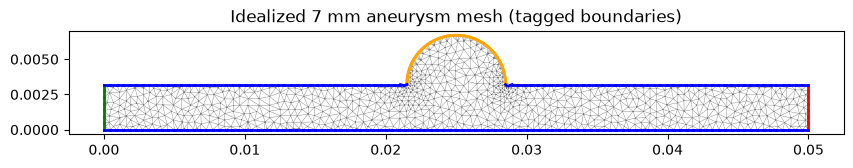

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.triplot(m.p[0], m.p[1], m.t.T, linewidth=0.3, color="gray")
colors = {"inlet": "g", "outlet": "r", "wall_vessel": "b", "wall_sac": "orange"}
for name, facets in m.boundaries.items():
    for f in facets:
        pts = m.p[:, m.facets[:, f]]
        ax.plot(pts[0], pts[1], color=colors[name], linewidth=2)
ax.set_aspect("equal")
ax.set_title("Idealized 7 mm aneurysm mesh (tagged boundaries)")
plt.show()

## Solve the steady Carreau-viscosity flow field

Inlet velocity 47 cm/s, matching the paper's experimental flow rate for
this geometry (Sec. 2.8). Mass conservation (inlet flux == outlet flux) is
checked as a basic sanity diagnostic -- see `tests/test_mechanistic_conservation.py`
for the full validation suite this notebook's checks summarize.

In [4]:
carreau = CarreauParams(mu_inf_pa_s=0.0035, mu_0_pa_s=0.056, lambda_s=3.313, n=0.3568)
flow = solve_steady_flow(tagged_mesh, inlet_velocity_m_s=0.47, carreau=carreau)
print(f"converged={flow.converged}, iterations={flow.n_iterations}, residual={flow.residual:.2e}")

q_in = compute_boundary_flux(flow, "inlet")
q_out = compute_boundary_flux(flow, "outlet")
print(f"flux in={q_in:.6e}, flux out={q_out:.6e}, relative imbalance={abs(q_in + q_out) / abs(q_in):.2e}")

converged=True, iterations=9, residual=5.71e-08
flux in=-1.504000e-03, flux out=1.504000e-03, relative imbalance=6.83e-14


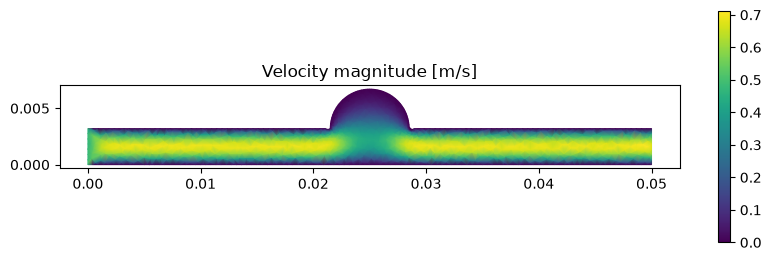

In [5]:
# Velocity magnitude at mesh vertices (P2 nodal dofs coincide with vertices
# for the corner/vertex nodes; this simple slice is sufficient for a quick look).
n_vertices = m.p.shape[1]
ux = flow.u[0 : 2 * n_vertices : 2]
uy = flow.u[1 : 2 * n_vertices : 2]
speed = np.hypot(ux, uy)

fig, ax = plt.subplots(figsize=(10, 3))
tpc = ax.tripcolor(m.p[0], m.p[1], m.t.T, speed, shading="gouraud", cmap="viridis")
ax.set_aspect("equal")
ax.set_title("Velocity magnitude [m/s]")
fig.colorbar(tpc, ax=ax)
plt.show()

## Next steps

Once `species_transport.py`, `activation.py`, `surface_ode.py`, `fibrin.py`,
and `coupled_solver.py` land, this notebook should be extended with:

- Wall shear rate and its axial gradient (Eqs. 6-7 mechanical
  aggregation trigger), reproducing Fig. 3b/c-style plots.
- Transient thrombus growth (M_at, FI fields over time), reproducing
  Fig. 4-6-style plots.
- A comparison against the paper's reported thrombus height for this
  geometry (Fig. 4a: approx. 6 mm at 120 min for the 7 mm aneurysm).